# Data Exploration - Breast Cancer Histopathology

This notebook explores the BreakHis dataset to understand:
- Dataset structure and organization
- Class distribution
- Image characteristics
- Sample visualizations

In [1]:
# Import required libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Structure

In [2]:
# Define data path
data_path = Path('../data')

# Check if data exists
if not data_path.exists():
    print("⚠️ Data folder not found!")
    print("Please download the BreakHis dataset and organize it as:")
    print("data/train/benign/")
    print("data/train/malignant/")
    print("data/valid/benign/")
    print("data/valid/malignant/")
else:
    print("✅ Data folder found!")
    
    # List directory structure
    for root, dirs, files in os.walk(data_path):
        level = root.replace(str(data_path), '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        if len(files) > 0:
            print(f"{subindent}({len(files)} files)")

✅ Data folder found!
data/
  train/
    benign/
      (1984 files)
    malignant/
      (4343 files)
  valid/
    benign/
      (496 files)
    malignant/
      (1086 files)


## 2. Class Distribution


📊 Image Distribution:
       benign  malignant
train    1984       4343
valid     496       1086

Total images: 7909


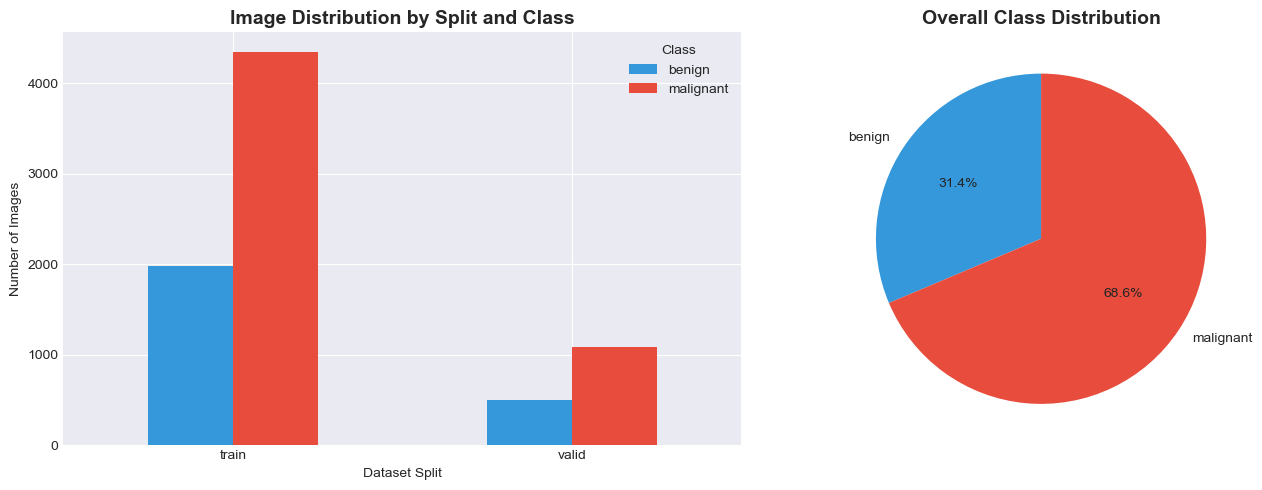

In [3]:
# Count images in each class
def count_images(path):
    """Count images in benign and malignant folders"""
    counts = {}
    for split in ['train', 'valid']:
        split_path = path / split
        if split_path.exists():
            benign_count = len(list((split_path / 'benign').glob('*.png'))) + \
                          len(list((split_path / 'benign').glob('*.jpg')))
            malignant_count = len(list((split_path / 'malignant').glob('*.png'))) + \
                             len(list((split_path / 'malignant').glob('*.jpg')))
            counts[split] = {'benign': benign_count, 'malignant': malignant_count}
    return counts

if data_path.exists():
    image_counts = count_images(data_path)
    
    # Create DataFrame for better visualization
    df_counts = pd.DataFrame(image_counts).T
    print("\n📊 Image Distribution:")
    print(df_counts)
    print(f"\nTotal images: {df_counts.sum().sum()}")
    
    # Visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    df_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
    axes[0].set_title('Image Distribution by Split and Class', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Dataset Split')
    axes[0].set_ylabel('Number of Images')
    axes[0].legend(title='Class')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Pie chart for total distribution
    total_counts = df_counts.sum()
    axes[1].pie(total_counts, labels=total_counts.index, autopct='%1.1f%%',
                colors=['#3498db', '#e74c3c'], startangle=90)
    axes[1].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 3. Sample Image Visualization

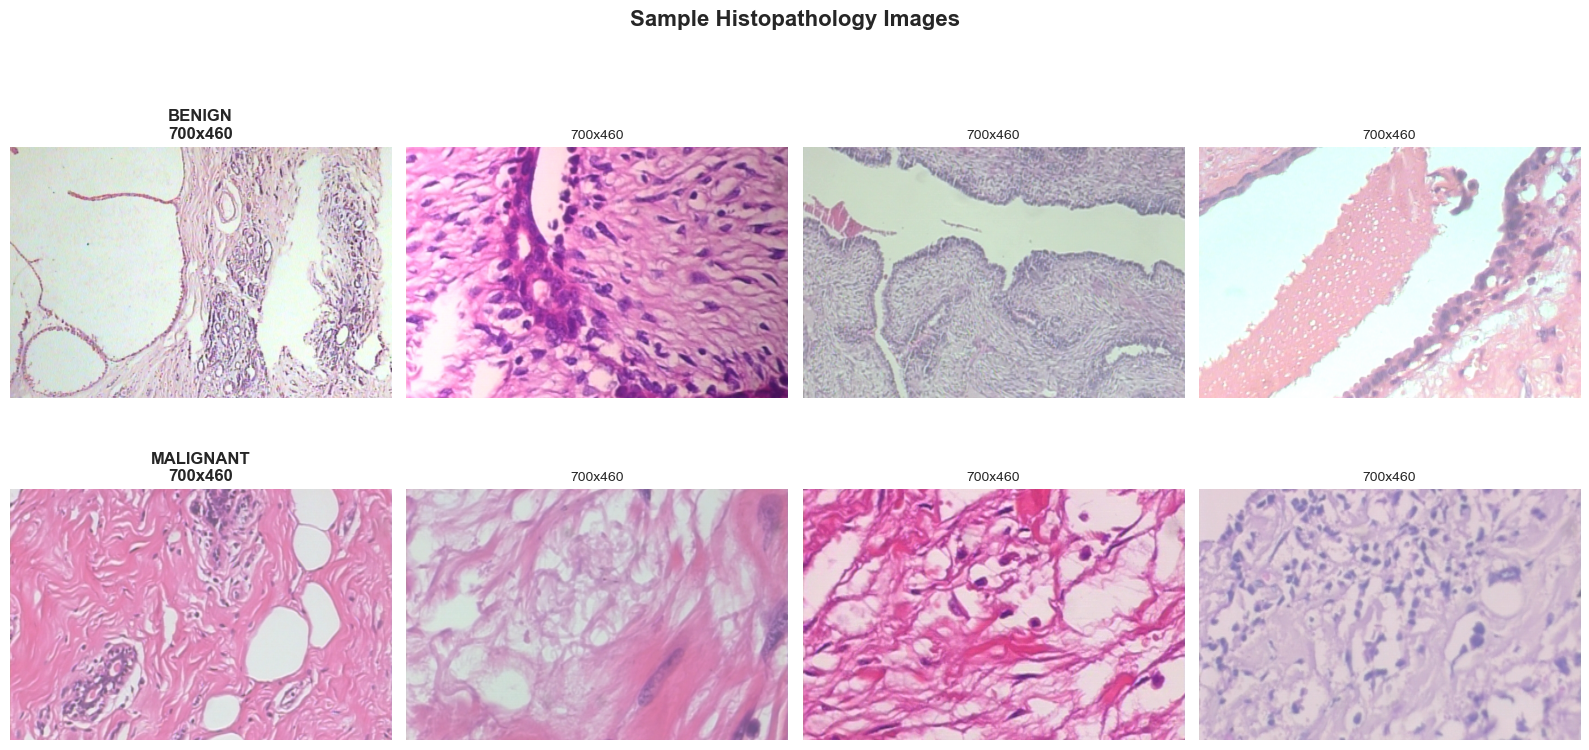

In [4]:
# Display sample images from each class
def show_samples(path, n_samples=4):
    """Display sample images from benign and malignant classes"""
    fig, axes = plt.subplots(2, n_samples, figsize=(16, 8))
    
    for idx, class_name in enumerate(['benign', 'malignant']):
        class_path = path / 'train' / class_name
        if class_path.exists():
            # Get image files
            image_files = list(class_path.glob('*.png')) + list(class_path.glob('*.jpg'))
            
            # Randomly select samples
            samples = np.random.choice(image_files, min(n_samples, len(image_files)), replace=False)
            
            for i, img_path in enumerate(samples):
                img = Image.open(img_path)
                axes[idx, i].imshow(img)
                axes[idx, i].axis('off')
                if i == 0:
                    axes[idx, i].set_title(f'{class_name.upper()}\n{img.size[0]}x{img.size[1]}',
                                          fontsize=12, fontweight='bold')
                else:
                    axes[idx, i].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=10)
    
    plt.suptitle('Sample Histopathology Images', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

if data_path.exists():
    show_samples(data_path, n_samples=4)

## 4. Image Properties Analysis

Analyzing image properties (this may take a moment)...

📏 Benign Images Statistics:
       width  height  mean_intensity  std_intensity
count   50.0    50.0       50.000000      50.000000
mean   700.0   460.0      185.371967      32.140633
std      0.0     0.0       13.505245      12.043091
min    700.0   460.0      156.495546      13.009913
25%    700.0   460.0      176.547010      24.123417
50%    700.0   460.0      185.014423      30.176716
75%    700.0   460.0      191.346015      40.781104
max    700.0   460.0      225.950333      61.671106

📏 Malignant Images Statistics:
       width  height  mean_intensity  std_intensity
count   50.0    50.0       50.000000      50.000000
mean   700.0   460.0      188.264807      36.997374
std      0.0     0.0       16.717963      11.000901
min    700.0   460.0      138.392877      23.458896
25%    700.0   460.0      181.164085      29.310763
50%    700.0   460.0      187.282017      32.765126
75%    700.0   460.0      193.938572      44.284096


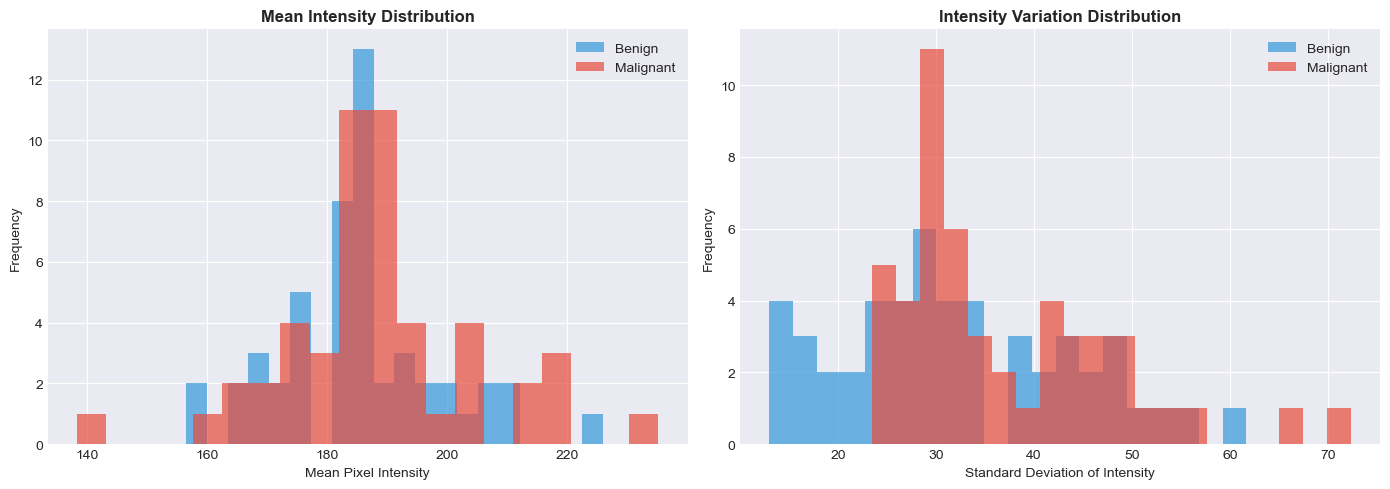

In [5]:
# Analyze image properties (size, color distribution, etc.)
def analyze_images(path, n_samples=50):
    """Analyze basic properties of images"""
    properties = {'benign': [], 'malignant': []}
    
    for class_name in ['benign', 'malignant']:
        class_path = path / 'train' / class_name
        if class_path.exists():
            image_files = list(class_path.glob('*.png')) + list(class_path.glob('*.jpg'))
            samples = np.random.choice(image_files, min(n_samples, len(image_files)), replace=False)
            
            for img_path in samples:
                img = Image.open(img_path)
                img_array = np.array(img)
                
                properties[class_name].append({
                    'width': img.size[0],
                    'height': img.size[1],
                    'mean_intensity': img_array.mean(),
                    'std_intensity': img_array.std()
                })
    
    return properties

if data_path.exists():
    print("Analyzing image properties (this may take a moment)...")
    props = analyze_images(data_path, n_samples=50)
    
    # Convert to DataFrames
    df_benign = pd.DataFrame(props['benign'])
    df_malignant = pd.DataFrame(props['malignant'])
    
    print("\n📏 Benign Images Statistics:")
    print(df_benign.describe())
    
    print("\n📏 Malignant Images Statistics:")
    print(df_malignant.describe())
    
    # Visualize intensity distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df_benign['mean_intensity'], bins=20, alpha=0.7, label='Benign', color='#3498db')
    axes[0].hist(df_malignant['mean_intensity'], bins=20, alpha=0.7, label='Malignant', color='#e74c3c')
    axes[0].set_xlabel('Mean Pixel Intensity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Mean Intensity Distribution', fontweight='bold')
    axes[0].legend()
    
    axes[1].hist(df_benign['std_intensity'], bins=20, alpha=0.7, label='Benign', color='#3498db')
    axes[1].hist(df_malignant['std_intensity'], bins=20, alpha=0.7, label='Malignant', color='#e74c3c')
    axes[1].set_xlabel('Standard Deviation of Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Intensity Variation Distribution', fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 5. Key Observations

Based on the exploration above, document your observations:

1. **Dataset Size**: [Fill in after running]
2. **Class Balance**: [Fill in after running]
3. **Image Dimensions**: [Fill in after running]
4. **Visual Differences**: [Describe what you notice between benign and malignant samples]

## Next Steps

- Proceed to `02_model_training.ipynb` to build and train the classification model
- Consider data augmentation strategies based on the dataset size
- Plan for handling class imbalance if present